

# **Telecom Customer Churn EDA**



Customer churn refers to customers ending the relationship with the a company. It reduces recurring revenue.
This analysis aims to identify behavioral and contract-related factors associated with churn in a telecom company.





**Dataset used: Kaggle – Telco Customer Churn Dataset**

 ## **Dataset overview**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#Basic Shape
df = pd.read_csv("Telco-Customer-Churn.csv")
df.shape

(7043, 21)

In [ ]:
#Preview
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Column Types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#Basic Statistics
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
#Churn Distribution

df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)


,proportion
Churn,
No,0.73463
Yes,0.26537


### **Insights**

* The dataset contains 7,043 customer records with 21 attributes covering demographics, contract details, and billing information.

* Approximately 26.5% of customers have churned, meaning roughly one in four customers discontinue service. This represents a significant revenue risk for a subscription-based telecom business.

## **Data Cleaning**

In [ ]:
df['TotalCharges'].dtype


dtype('O')

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [ ]:
df['TotalCharges'].isna().sum()



np.int64(11)

In [ ]:
df[df['TotalCharges'].isna()]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
df.isna().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


All the nan values are from total charges. A new customer with tenure 0 hasn't generated charges yet. Thus dropping the missing values is the best move

In [ ]:
df = df.dropna()
df.shape


(7032, 21)

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df['Contract'].unique()


array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [ ]:
df['Churn'].unique()


array(['No', 'Yes'], dtype=object)

## **Univariate Profiling**

### **Tenure**

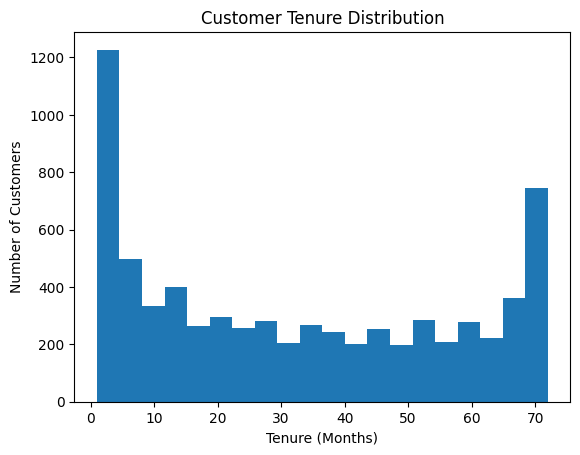

In [ ]:
plt.hist(df['tenure'], bins=20)
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Customer Tenure Distribution")
plt.show()


### **Monthly Charges**

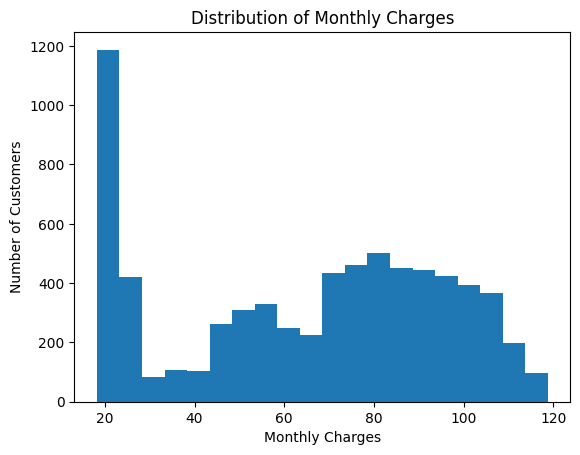

In [ ]:
plt.hist(df['MonthlyCharges'], bins=20)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

### **Contract Distribution**

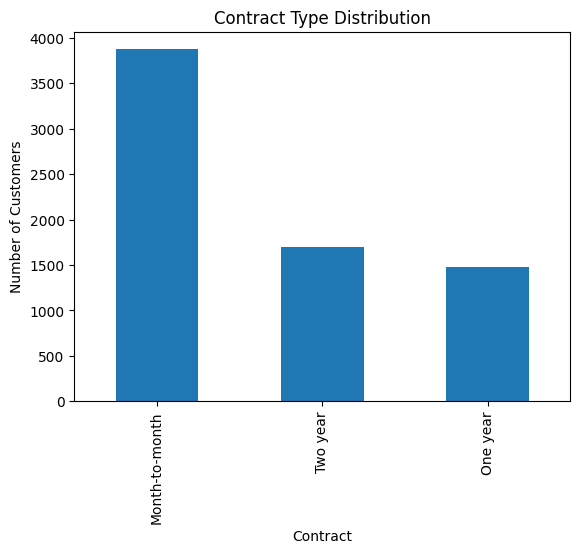

In [ ]:
df['Contract'].value_counts().plot(kind='bar')
plt.title("Contract Type Distribution")
plt.ylabel("Number of Customers")
plt.show()

### **Internet Service Distribution**

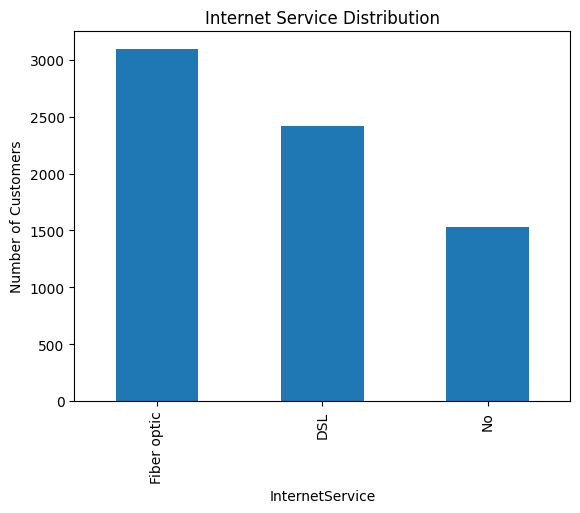

In [ ]:
df['InternetService'].value_counts().plot(kind='bar')
plt.title("Internet Service Distribution")
plt.ylabel("Number of Customers")
plt.show()

### **Insights**
* The tenure distribution shows a high concentration of new customers (low tenure), along with a secondary concentration of long-tenured customers (~70+ months), suggesting a mix of newly acquired and highly retained users.

* Monthly charges are broadly distributed across a wide range, with a noticeable cluster at lower pricing tiers and a substantial number of customers in higher pricing brackets, indicating multiple service tiers.

* A significant proportion of customers are on month-to-month contracts, while long-term (one-year and two-year) contracts represent a smaller share of the customer base.

* Fiber optic service represents the largest segment of customers, followed by DSL, while a smaller proportion of customers do not subscribe to internet services.

## **Churn Relationships**

In [ ]:
churn_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
churn_contract

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


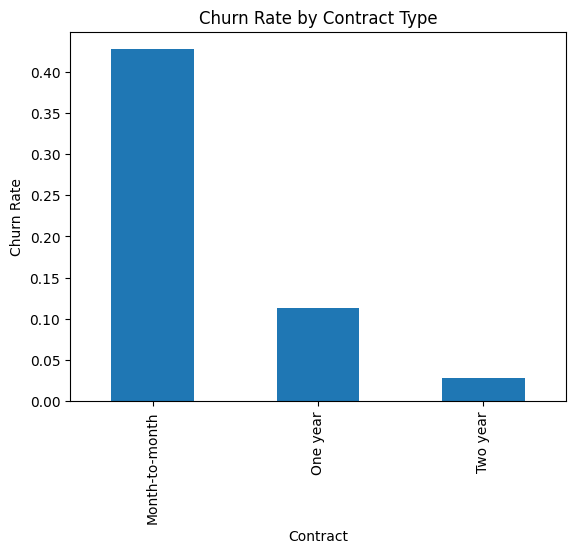

In [ ]:
churn_contract['Yes'].plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

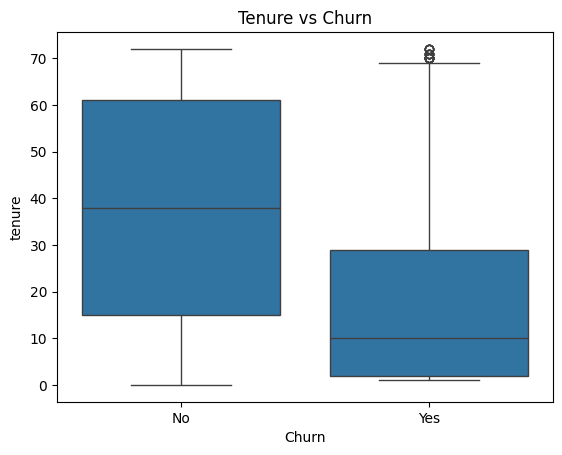

In [ ]:
import seaborn as sns

sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

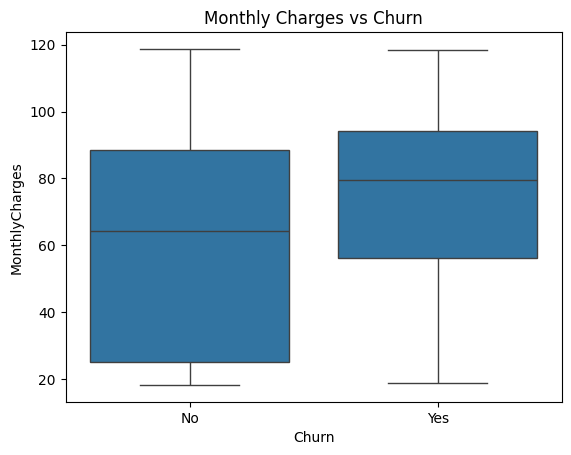

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


In [ ]:
churn_internet = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
churn_internet

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


### **Insights**
* Contract type is a strong indicator of customer retention. Month-to-month customers exhibit a churn rate of approximately 43%, significantly higher than customers on one-year (11%) and two-year contracts (3%). This suggests that longer contractual commitments substantially improve customer retention.
* Customers with shorter tenure are significantly more likely to churn, while long-term customers demonstrate much higher retention.
* Customers who churn tend to have higher monthly charges compared to retained customers. This suggests that higher pricing tiers may experience greater customer dissatisfaction or price sensitivity.
* Fiber optic customers exhibit the highest churn rate (~42%) compared to DSL (~19%) and customers without internet service (~7%). This suggests potential dissatisfaction or pricing sensitivity among fiber optic users.

## **Key Findings & Business Recommendations**

### **Key Findings**

1. Contract Type is the strongest predictor of churn

Customers on month-to-month contracts exhibit a churn rate of approximately 43%, which is significantly higher than customers on one-year (11%) and two-year contracts (3%).
This indicates that long-term contractual commitments significantly improve customer retention.

2. Customer tenure is strongly associated with churn

Customers who churn generally have much lower tenure compared to retained customers.
This suggests that the early lifecycle period is the highest-risk phase for churn.

3. Higher monthly charges are associated with increased churn

Customers who churn tend to have higher monthly charges on average compared to retained customers.
This indicates possible price sensitivity or dissatisfaction among higher-tier service users.

4. Fiber optic service customers exhibit the highest churn

Customers using fiber optic internet services show the highest churn rate (42%), significantly higher than DSL (19%) and customers without internet (7%).
This suggests potential service quality concerns, pricing issues, or unmet expectations among fiber optic users.

### **Business Recommendations**

1. Encourage migration to long-term contracts

Telecom providers should incentivize customers to move from month-to-month plans to one-year or two-year contracts through discounts or bundled offers.

2. Focus retention efforts on new customers

Since churn is highest during the early tenure period, companies should improve customer onboarding, early support, and promotional incentives during the first few months.

3. Review pricing strategies for high-tier plans

The higher churn observed among customers with higher monthly charges suggests a need to reassess pricing structures and perceived value of premium plans.

4. Investigate fiber optic service experience

The significantly higher churn among fiber optic customers warrants deeper investigation into service reliability, pricing competitiveness, and customer satisfaction.